In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
import sys
sys.path.append("D:/DataMining/BTL_DataMining")

In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA

from src.features.builder import build_features, build_product_basket
from src.mining.association import mine_association_rules
from src.mining.clustering import run_kmeans_clustering

sns.set_style("whitegrid")

In [11]:
df = pd.read_csv("../data/raw/bank-additional-full.csv", sep=";")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
!pip install mlxtend

In [12]:
df = build_features(df)

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,age_group,has_loan,total_contacts,contact_rate,potential_client
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,93.994,-36.4,4.857,5191.0,no,senior,0,1,1.0,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,93.994,-36.4,4.857,5191.0,no,senior,0,1,1.0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,93.994,-36.4,4.857,5191.0,no,mid_age,1,1,1.0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,93.994,-36.4,4.857,5191.0,no,mid_age,0,1,1.0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,93.994,-36.4,4.857,5191.0,no,senior,1,1,1.0,0


In [13]:
basket = build_product_basket(df)

basket.head()

,housing_loan,personal_loan,subscribed_deposit
0,False,False,False
1,False,False,False
2,True,False,False
3,False,False,False
4,False,True,False


In [14]:
rules = mine_association_rules(basket)

rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(personal_loan),(housing_loan),0.151695,0.523842,0.089613,0.590749,1.127724,1.0,0.010149,1.163487,0.133511,0.152944,0.140515,0.380909
1,(subscribed_deposit),(housing_loan),0.112654,0.523842,0.060867,0.540302,1.031421,1.0,0.001854,1.035806,0.034332,0.105740,0.034568,0.328248


In [15]:
top_rules = rules.sort_values("lift", ascending=False).head(10)

top_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(personal_loan),(housing_loan),0.151695,0.523842,0.089613,0.590749,1.127724,1.0,0.010149,1.163487,0.133511,0.152944,0.140515,0.380909
1,(subscribed_deposit),(housing_loan),0.112654,0.523842,0.060867,0.540302,1.031421,1.0,0.001854,1.035806,0.034332,0.105740,0.034568,0.328248


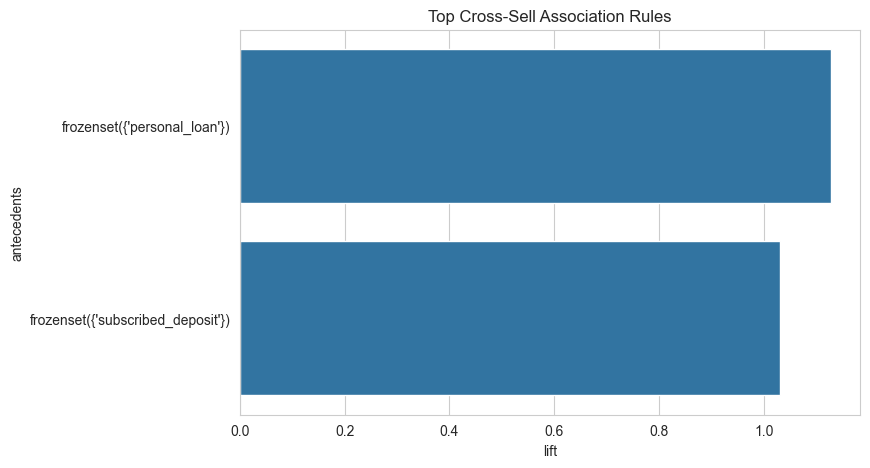

In [16]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=top_rules["lift"],
    y=top_rules["antecedents"].astype(str)
)

plt.title("Top Cross-Sell Association Rules")

plt.show()

In [17]:
df_clustered, X_scaled, sil, dbi = run_kmeans_clustering(df)

print("Silhouette Score:", sil)
print("Davies Bouldin Index:", dbi)

df_clustered.head()

Silhouette Score: 0.38189099679690547
Davies Bouldin Index: 1.023060696823617


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,cons.conf.idx,euribor3m,nr.employed,y,age_group,has_loan,total_contacts,contact_rate,potential_client,cluster
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,-36.4,4.857,5191.0,no,senior,0,1,1.0,0,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,-36.4,4.857,5191.0,no,senior,0,1,1.0,0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,-36.4,4.857,5191.0,no,mid_age,1,1,1.0,0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,-36.4,4.857,5191.0,no,mid_age,0,1,1.0,0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,-36.4,4.857,5191.0,no,senior,1,1,1.0,0,0


In [18]:
df_clustered["cluster"].value_counts()

cluster
0    26082
1    11957
2     1633
3     1516
Name: count, dtype: int64

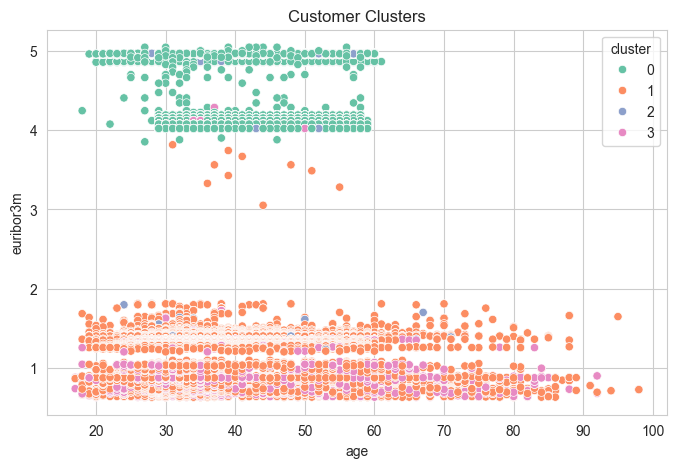

In [19]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="age",
    y="euribor3m",
    hue="cluster",
    data=df_clustered,
    palette="Set2"
)

plt.title("Customer Clusters")

plt.show()

In [20]:
cluster_profile = df_clustered.groupby("cluster").mean(numeric_only=True)

cluster_profile

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,has_loan,total_contacts,contact_rate,potential_client
cluster,,,,,,,,,,,,,,
0,40.175102,256.582279,2.200982,999.000000,0.026723,1.105958,93.837102,-39.431550,4.812435,5212.999916,0.568898,2.227705,2.176175,0.000000
1,39.412980,264.324329,2.067492,999.000000,0.325918,-2.025634,92.988768,-43.164046,1.201021,5077.705662,0.622481,2.393410,1.768621,0.000000
2,40.385181,182.672994,12.776485,999.000000,0.004899,1.178873,93.913382,-40.128230,4.764591,5214.934109,0.564605,12.781384,12.745867,0.000000
3,41.856201,321.393799,1.822559,6.669525,1.663588,-2.095976,93.342958,-38.341359,0.985895,5029.219855,0.613456,3.486148,0.748820,0.905673


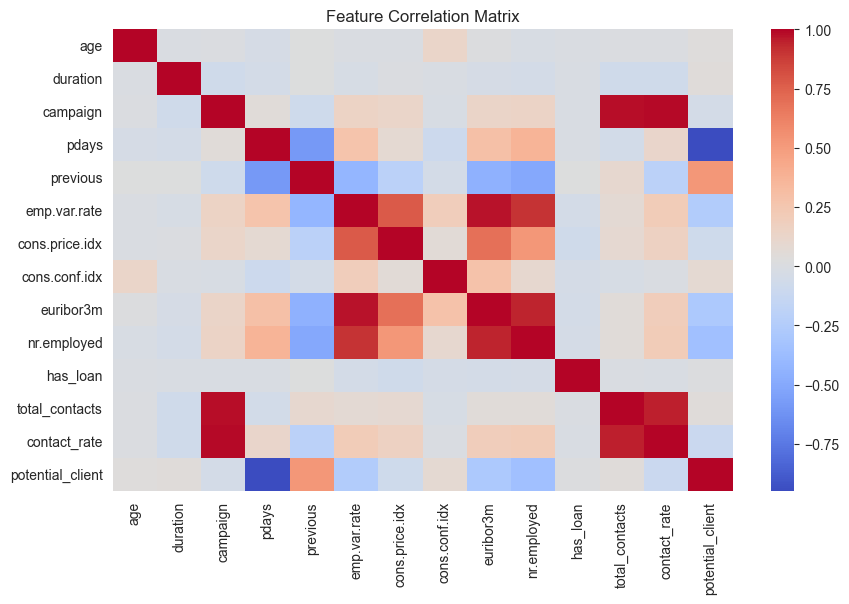

In [21]:
plt.figure(figsize=(10,6))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap="coolwarm")

plt.title("Feature Correlation Matrix")

plt.show()

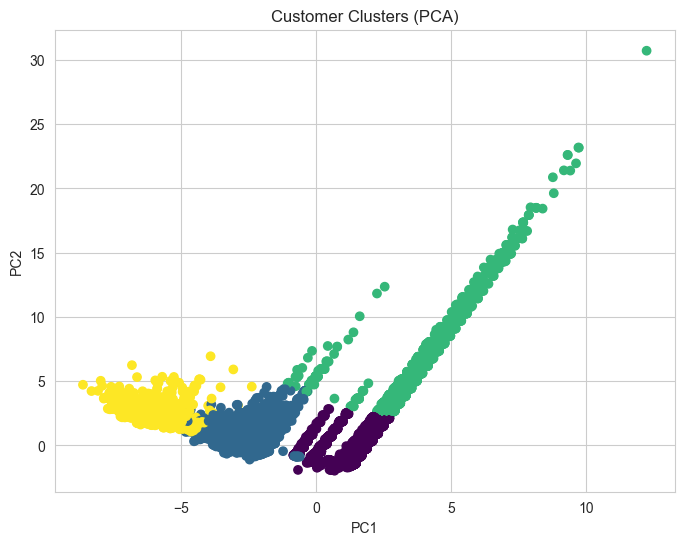

In [22]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df_clustered["cluster"],
    cmap="viridis"
)

plt.title("Customer Clusters (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

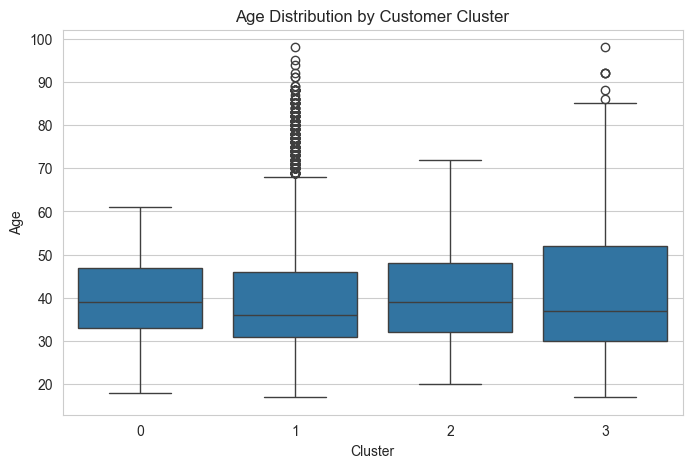

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="cluster",
    y="age",
    data=df_clustered
)

plt.title("Age Distribution by Customer Cluster")
plt.xlabel("Cluster")
plt.ylabel("Age")

plt.show()

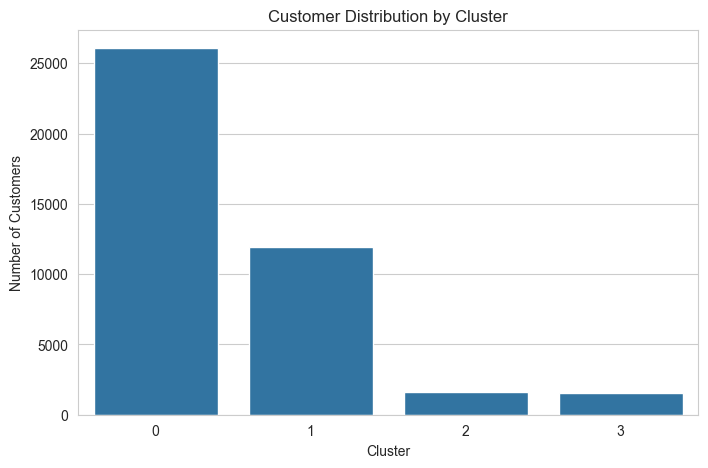

In [24]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="cluster",
    data=df_clustered
)

plt.title("Customer Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

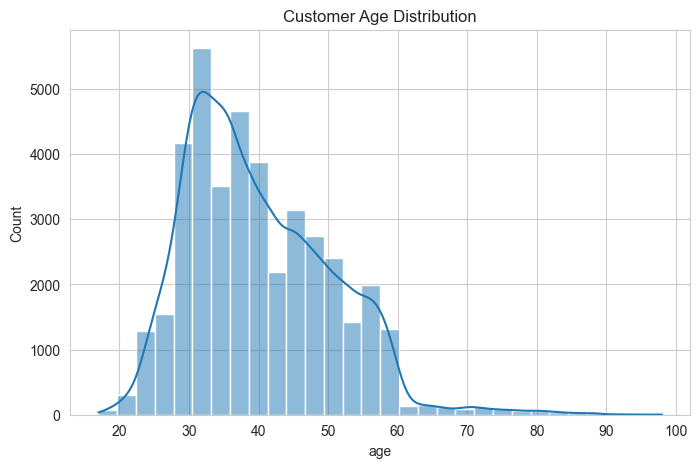

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_clustered["age"],
    bins=30,
    kde=True
)

plt.title("Customer Age Distribution")

plt.show()